# Snoozy Meditation Classifier

Binary classifier: **meditation vs. mind-wandering** from the OpenNeuro ds001787 probed EEG sessions.

Hardware target: **nRF54L15 + ADS1299-4 + BNO086**

Design choices:
- 10-second window before each probe onset
- 4 EEG channels selected from the research dataset to match the wearable electrode positions (Fp1, Fp2, AF7, AF8)
- Real-time-computable features: per-channel PSD bands, sub-bands, ratios, Hjorth params, spectral entropy, ZCR + cross-channel coherence and asymmetry
- Leave-One-Participant-Out (LOPO) cross-validation
- Export to ONNX for on-device inference

**Referencing note:** each ADS1299 input is wired as `FpX(+) / AFz(−)` so both channels share a common midline forehead reference. This gives the ADS1299's differential CMRR without collapsing to a single bipolar channel. The cross-channel asymmetry features (log Fp2_α − log Fp1_α, etc.) capture the same lateralization information that a hardware Fp1−Fp2 bipolar would, while keeping both channels available for per-channel features.

## Imports

In [1]:
from __future__ import annotations

import json
import math
import time
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.signal import coherence, welch
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")

## Configuration

In [ ]:
DATA_ROOT = Path("dataset/ds001787")
ARTIFACTS_DIR = Path("artifacts")

# --- EEG window ---
CONTEXT_SEC  = 10.0  # pre-probe context: total duration to extract sliding windows from
WINDOW_SEC   = 5.0   # feature window length (each sliding window)
STEP_SEC     = 0.5   # step between consecutive windows → 11 windows per probe
N_SUBWINDOWS = 5     # split each window into N chunks for intra-window variability features
LOWCUT       = 0.5   # Hz  (bandpass pre-processing)
HIGHCUT      = 40.0  # Hz

# --- Channel selection ---
# BioSemi labelling: A1=Fp1, B2=Fp2, A2=AF7, B3=AF8, B1=Fpz
# ADS1299-4 differential inputs:
#   Ch1: (Fp1−Fp2)  Ch2: (AF7−AF8)  BIAS/REF: Fpz
# We compute (Fp1−Fp2)−Fpz and (AF7−AF8)−Fpz to match the hardware derivation.
PRIMARY_CHANNELS  = ["A1", "B2", "A2", "B3"]  # Fp1, Fp2, AF7, AF8 (needed for bipolars)
REFERENCE_CHANNEL = "B1"                        # Fpz — subtracted from each bipolar pair
BIPOLAR_LABELS    = ["Fp1-Fp2", "AF7-AF8"]     # logical channel names for feature naming
N_CHANNELS_REQUIRED = 4                         # all 4 primaries must be present

# --- Label mapping ---
Q2_LABEL: Dict[int, str] = {2: "meditation", 4: "mind_wandering", 8: "mind_wandering"}
TARGET_LABELS = ["meditation", "mind_wandering"]

# --- Spectral bands ---
BANDS = {
    "delta":  (0.5,  4.0),
    "theta":  (4.0,  8.0),
    "alpha":  (8.0, 12.0),
    "sigma":  (12.0, 16.0),
    "beta":   (16.0, 30.0),
}
SUB_BANDS = {
    "theta1": (4.0,  6.0),
    "theta2": (6.0,  8.0),
    "alpha1": (8.0, 10.0),
    "alpha2": (10.0, 12.0),
}

RANDOM_STATE = 42
_n_wins_per_probe = int((CONTEXT_SEC - WINDOW_SEC) / STEP_SEC) + 1
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"Sliding windows per probe: {_n_wins_per_probe}  "
      f"({CONTEXT_SEC:.0f}s context, {WINDOW_SEC:.0f}s window, {STEP_SEC}s step)")

## Feature Extraction

All features are computable in real-time from a single 5-second window on the nRF54L15 (Cortex-M33).

Feature layout (64 total):
- **Per channel × 2** (F7, F8): 5 band abs powers, 5 rel powers, 4 band ratios, 3 Hjorth, spectral entropy, ZCR, mean/std/rms, 4 sub-band powers, theta peak freq, alpha peak freq → **32 × 2 = 64** per channel
- Subtract cross-channel features from the count: **56 per-channel + 8 cross-channel = 64 total**

In [ ]:
def _band_power(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    return float(np.sum(psd[mask])) if np.any(mask) else 0.0


def _peak_freq(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return (lo + hi) / 2.0
    return float(freqs[mask][np.argmax(psd[mask])])


def _spectral_entropy(psd: np.ndarray) -> float:
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log(p + 1e-12)))


def _spectral_edge_freq(psd: np.ndarray, freqs: np.ndarray, threshold: float = 0.95) -> float:
    """SEF95: lowest frequency below which `threshold` fraction of total power lies."""
    cumsum = np.cumsum(psd)
    target = threshold * cumsum[-1]
    idx = int(np.searchsorted(cumsum, target))
    return float(freqs[min(idx, len(freqs) - 1)])


def _permutation_entropy(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    """Permutation entropy — captures ordinal complexity/irregularity of the signal.

    High PE → irregular (mind-wandering); low PE → structured (meditation).
    Runs in O(n) with a dict-based ordinal pattern counter.
    """
    n = len(x)
    run_len = delay * (order - 1)
    if n <= run_len:
        return 0.0
    counts: dict = {}
    for i in range(n - run_len):
        pattern = tuple(np.argsort(x[i: i + run_len + 1: delay], kind="stable"))
        counts[pattern] = counts.get(pattern, 0) + 1
    total = sum(counts.values())
    probs = np.array(list(counts.values()), dtype=np.float64) / total
    return float(-np.sum(probs * np.log2(probs + 1e-12)))


def _hjorth(x: np.ndarray) -> Tuple[float, float, float]:
    """Activity, Mobility, Complexity."""
    activity = float(np.var(x))
    d1 = np.diff(x)
    mobility = float(np.sqrt(np.var(d1) / (activity + 1e-12)))
    d2 = np.diff(d1)
    mob_d1 = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-12)))
    complexity = mob_d1 / (mobility + 1e-12)
    return activity, mobility, complexity


def channel_features(x: np.ndarray, fs: float) -> List[float]:
    """30 features from a single EEG channel."""
    x = x.astype(np.float64)
    nperseg = min(int(fs), len(x))
    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    total_power = float(np.sum(psd)) + 1e-12

    band_abs = {name: _band_power(psd, freqs, lo, hi) for name, (lo, hi) in BANDS.items()}
    band_rel = {name: v / total_power for name, v in band_abs.items()}

    feats: List[float] = []
    for name in BANDS:
        feats.append(band_abs[name])
    for name in BANDS:
        feats.append(band_rel[name])

    theta, alpha = band_abs["theta"], band_abs["alpha"]
    delta, beta  = band_abs["delta"],  band_abs["beta"]
    feats.append(theta / (alpha + 1e-12))
    feats.append(delta / (beta  + 1e-12))
    feats.append(alpha / (beta  + 1e-12))
    feats.append(theta / (beta  + 1e-12))

    feats.extend(_hjorth(x))
    feats.append(_spectral_entropy(psd))
    feats.append(float(np.mean(np.diff(np.signbit(x)) != 0)))
    feats.append(float(np.mean(x)))
    feats.append(float(np.std(x)))
    feats.append(float(np.sqrt(np.mean(x ** 2))))

    for lo, hi in SUB_BANDS.values():
        feats.append(_band_power(psd, freqs, lo, hi))

    feats.append(_peak_freq(psd, freqs, *BANDS["theta"]))
    feats.append(_peak_freq(psd, freqs, *BANDS["alpha"]))

    # YASA-inspired additions
    feats.append(_spectral_edge_freq(psd, freqs, 0.95))   # SEF95
    feats.append(_permutation_entropy(x, order=3, delay=1))  # PE

    return feats  # 5+5+4+3+1+1+3+4+2+2 = 30


def subwindow_features(x: np.ndarray, fs: float) -> List[float]:
    """7 intra-window variability features from a single channel.

    Splits the window into N_SUBWINDOWS equal chunks and computes:
      - std of each band power across chunks (5 features)
      - linear slope of theta and alpha across chunks (2 features)
    """
    x = x.astype(np.float64)
    n = len(x)
    chunk_size = n // N_SUBWINDOWS

    bp = np.zeros((N_SUBWINDOWS, len(BANDS)))
    for wi in range(N_SUBWINDOWS):
        chunk = x[wi * chunk_size: (wi + 1) * chunk_size]
        nperseg = min(int(fs), len(chunk))
        freqs, psd = welch(chunk, fs=fs, nperseg=nperseg)
        for bi, (lo, hi) in enumerate(BANDS.values()):
            bp[wi, bi] = _band_power(psd, freqs, lo, hi)

    feats: List[float] = list(bp.std(axis=0))  # 5: std per band across sub-windows

    t = np.arange(N_SUBWINDOWS, dtype=np.float64)
    feats.append(float(np.polyfit(t, bp[:, 1], 1)[0]))  # theta slope
    feats.append(float(np.polyfit(t, bp[:, 2], 1)[0]))  # alpha slope

    return feats  # 7 features


def cross_channel_features(eeg: np.ndarray, fs: float) -> List[float]:
    """8 features per channel pair: 3 coherence + 1 corr + 4 log-asymmetry."""
    n_ch    = eeg.shape[0]
    nperseg = min(int(fs), eeg.shape[1])
    feats: List[float] = []

    psds: List[np.ndarray] = []
    freqs_ref: np.ndarray  = None
    for i in range(n_ch):
        freqs_ref, psd = welch(eeg[i].astype(np.float64), fs=fs, nperseg=nperseg)
        psds.append(psd)

    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            ch_i = eeg[i].astype(np.float64)
            ch_j = eeg[j].astype(np.float64)

            for band_name in ("theta", "alpha", "beta"):
                lo, hi = BANDS[band_name]
                f_coh, cxy = coherence(ch_i, ch_j, fs=fs, nperseg=nperseg)
                mask = (f_coh >= lo) & (f_coh < hi)
                feats.append(float(np.mean(cxy[mask])) if np.any(mask) else 0.0)

            corr = float(np.corrcoef(ch_i, ch_j)[0, 1])
            feats.append(corr if np.isfinite(corr) else 0.0)

            for band_name in ("alpha", "theta", "delta", "beta"):
                lo, hi = BANDS[band_name]
                p_i = _band_power(psds[i], freqs_ref, lo, hi)
                p_j = _band_power(psds[j], freqs_ref, lo, hi)
                feats.append(float(np.log(p_j + 1e-12) - np.log(p_i + 1e-12)))

    return feats  # 8 × n_ch*(n_ch-1)/2 pairs


def extract_features(eeg: np.ndarray, fs: float) -> np.ndarray:
    """Full feature vector for an N-channel EEG epoch (shape: N × samples)."""
    feats: List[float] = []
    for ch in range(eeg.shape[0]):
        feats.extend(channel_features(eeg[ch], fs))
    feats.extend(cross_channel_features(eeg, fs))
    for ch in range(eeg.shape[0]):
        feats.extend(subwindow_features(eeg[ch], fs))
    return np.asarray(feats, dtype=np.float32)


def feature_names(ch_names: Sequence[str]) -> List[str]:
    """Ordered list of feature names matching extract_features output."""
    names: List[str] = []
    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_abs")
        for band in BANDS:
            names.append(f"{ch}_{band}_rel")
        names += [f"{ch}_theta_alpha", f"{ch}_delta_beta", f"{ch}_alpha_beta", f"{ch}_theta_beta"]
        names += [f"{ch}_hjorth_act", f"{ch}_hjorth_mob", f"{ch}_hjorth_cplx"]
        names.append(f"{ch}_spec_entropy")
        names.append(f"{ch}_zcr")
        names += [f"{ch}_mean", f"{ch}_std", f"{ch}_rms"]
        for sub in SUB_BANDS:
            names.append(f"{ch}_{sub}_abs")
        names.append(f"{ch}_theta_peak_hz")
        names.append(f"{ch}_alpha_peak_hz")
        names.append(f"{ch}_sef95")
        names.append(f"{ch}_perm_entropy")

    for i, chi in enumerate(ch_names):
        for j, chj in enumerate(ch_names):
            if j <= i:
                continue
            pair = f"{chi}_{chj}"
            names += [f"coh_theta_{pair}", f"coh_alpha_{pair}", f"coh_beta_{pair}"]
            names.append(f"corr_{pair}")
            names += [f"asym_alpha_{pair}", f"asym_theta_{pair}",
                      f"asym_delta_{pair}", f"asym_beta_{pair}"]

    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_std_sw")
        names.append(f"{ch}_theta_slope_sw")
        names.append(f"{ch}_alpha_slope_sw")

    return names


# Smoke-test — 2 bipolar channels, 30 per-channel features
_n_ch    = len(BIPOLAR_LABELS)   # 2
_n_pairs = _n_ch * (_n_ch - 1) // 2  # 1
_n_sw    = 7
_expected = _n_ch * 30 + _n_pairs * 8 + _n_ch * _n_sw  # 60 + 8 + 14 = 82
_dummy_eeg   = np.random.randn(_n_ch, int(256 * WINDOW_SEC)).astype(np.float32)
_dummy_feats = extract_features(_dummy_eeg, fs=256.0)
_dummy_names = feature_names(BIPOLAR_LABELS)
print(f"Channels: {_n_ch}  →  {_n_ch*30} per-channel + {_n_pairs*8} cross-channel + {_n_ch*_n_sw} subwindow = {_expected} total")
print(f"Feature vector length : {len(_dummy_feats)}")
print(f"Feature names length  : {len(_dummy_names)}")
assert len(_dummy_feats) == len(_dummy_names) == _expected, \
    f"Feature count mismatch: feats={len(_dummy_feats)}, names={len(_dummy_names)}, expected={_expected}"
print("Feature extraction OK")

## Dataset Loading

Selects F7 and F8 from each recording. Falls back to the best-available frontal pair if either channel is missing.

Probe label extraction follows the Q2 convention: stimulus/128 → responses → Q2 is the second response value (2=meditation, 4/8=mind_wandering). Adapted from `med_model.py`.

In [ ]:
def _has_required_channels(raw: mne.io.BaseRaw) -> bool:
    """Return True if all PRIMARY_CHANNELS and REFERENCE_CHANNEL are present."""
    available = set(raw.ch_names)
    return all(ch in available for ch in PRIMARY_CHANNELS + [REFERENCE_CHANNEL])


def _extract_probe_label(events_df: pd.DataFrame, probe_idx: int) -> Optional[str]:
    """Q2 label from the response rows that follow a probe onset."""
    responses: List[int] = []
    for j in range(probe_idx + 1, len(events_df)):
        row = events_df.iloc[j]
        tt = str(row.get("trial_type", "")).strip().lower()
        val = row.get("value")
        if tt == "stimulus" and pd.notna(val) and int(val) == 128:
            break
        if tt == "response" and pd.notna(val) and int(val) in Q2_LABEL:
            responses.append(int(val))
        if len(responses) == 3:
            break
    if len(responses) < 2:
        return None
    return Q2_LABEL.get(responses[1])


def _find_recording_pairs(sub_dir: Path) -> List[Tuple[Path, Path]]:
    pairs: List[Tuple[Path, Path]] = []
    for ses_dir in sorted(sub_dir.glob("ses-*")):
        if not ses_dir.is_dir():
            continue
        eeg_dir = ses_dir / "eeg"
        if not eeg_dir.is_dir():
            continue
        for eeg_path in sorted(eeg_dir.iterdir()):
            if eeg_path.suffix.lower() not in {".edf", ".bdf", ".set", ".fif"}:
                continue
            if "task-meditation" not in eeg_path.name:
                continue
            if f"_eeg{eeg_path.suffix}" not in eeg_path.name:
                continue
            events_path = eeg_path.with_name(
                eeg_path.name.replace(f"_eeg{eeg_path.suffix}", "_events.tsv")
            )
            if events_path.exists():
                pairs.append((eeg_path, events_path))
    return pairs


def _read_raw(eeg_path: Path) -> mne.io.BaseRaw:
    readers = {".edf": mne.io.read_raw_edf, ".bdf": mne.io.read_raw_bdf,
               ".set": mne.io.read_raw_eeglab, ".fif": mne.io.read_raw_fif}
    fn = readers.get(eeg_path.suffix.lower())
    if fn is None:
        raise ValueError(f"Unsupported format: {eeg_path.suffix}")
    return fn(eeg_path, preload=True, verbose="ERROR")


def load_dataset(
    ds_root: Path,
    context_sec: float = CONTEXT_SEC,
    window_sec: float = WINDOW_SEC,
    step_sec: float = STEP_SEC,
    max_subjects: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str], float]:
    """
    Returns X, y, groups, probe_ids, channel_names, sampling_freq.

    For each probe event, a sliding window is applied over the CONTEXT_SEC
    pre-probe EEG. Each WINDOW_SEC window (step STEP_SEC) yields one feature
    vector with the same Q2 label. probe_ids ties every window back to its
    originating probe so predictions can be aggregated at probe level.

    Two bipolar derivations per window:
      Ch0 = (Fp1 − Fp2) − Fpz   (A1 − B2 − B1)
      Ch1 = (AF7 − AF8) − Fpz   (A2 − B3 − B1)
    """
    subject_dirs = sorted(p for p in ds_root.glob("sub-*") if p.is_dir())
    if max_subjects is not None:
        subject_dirs = subject_dirs[:max_subjects]

    canonical_sfreq: Optional[float] = None
    all_X:         List[np.ndarray] = []
    all_y:         List[str]        = []
    all_groups:    List[str]        = []
    all_probe_ids: List[str]        = []

    load_chs = PRIMARY_CHANNELS + [REFERENCE_CHANNEL]

    for sub_dir in subject_dirs:
        pairs = _find_recording_pairs(sub_dir)
        if not pairs:
            print(f"  skip {sub_dir.name}: no meditation EEG pairs")
            continue

        subj_windows = 0
        for rec_idx, (eeg_path, events_path) in enumerate(pairs):
            try:
                raw = _read_raw(eeg_path)
            except Exception as exc:
                print(f"  skip {eeg_path.name}: {exc}")
                continue

            if not _has_required_channels(raw):
                print(f"  skip {eeg_path.name}: required channels {load_chs} not all present")
                continue

            raw.pick(load_chs)
            raw.filter(LOWCUT, HIGHCUT, verbose="ERROR")

            sfreq = float(raw.info["sfreq"])
            if canonical_sfreq is None:
                canonical_sfreq = sfreq
            elif abs(sfreq - canonical_sfreq) > 1e-6:
                raw.resample(canonical_sfreq, npad="auto")
                sfreq = canonical_sfreq

            context_samples = int(round(context_sec * sfreq))
            window_samples  = int(round(window_sec  * sfreq))
            step_samples    = int(round(step_sec    * sfreq))

            idx = {ch: raw.ch_names.index(ch) for ch in load_chs}

            try:
                events_df = pd.read_csv(events_path, sep="\t")
            except Exception as exc:
                print(f"  skip {events_path.name}: {exc}")
                continue

            if not {"onset", "trial_type", "value"}.issubset(events_df.columns):
                print(f"  skip {events_path.name}: missing required columns")
                continue

            probe_counter = 0
            for i, row in events_df.iterrows():
                tt  = str(row.get("trial_type", "")).strip().lower()
                val = row.get("value")
                if tt != "stimulus" or pd.isna(val) or int(val) != 128:
                    continue

                label = _extract_probe_label(events_df, i)
                if label not in TARGET_LABELS:
                    continue

                probe_sample  = int(round(float(row["onset"]) * sfreq))
                context_start = probe_sample - context_samples
                if context_start < 0 or probe_sample > raw.n_times:
                    continue

                probe_id = f"{sub_dir.name}_r{rec_idx}_p{probe_counter}"
                probe_counter += 1

                data_ctx = raw.get_data(start=context_start, stop=probe_sample)
                fpz_ctx  = data_ctx[idx[REFERENCE_CHANNEL]]

                win_offset = 0
                while win_offset + window_samples <= context_samples:
                    seg = data_ctx[:, win_offset: win_offset + window_samples]
                    fpz = fpz_ctx[win_offset: win_offset + window_samples]

                    segment = np.stack([
                        seg[idx["A1"]] - seg[idx["B2"]] - fpz,
                        seg[idx["A2"]] - seg[idx["B3"]] - fpz,
                    ]).astype(np.float32)

                    all_X.append(extract_features(segment, fs=sfreq))
                    all_y.append(label)
                    all_groups.append(sub_dir.name)
                    all_probe_ids.append(probe_id)
                    subj_windows += 1
                    win_offset += step_samples

        print(f"  {sub_dir.name}: {subj_windows} windows")

    if not all_X:
        raise ValueError("No usable epochs found — check DATA_ROOT and channel names")

    X         = np.vstack(all_X).astype(np.float32)
    y         = np.asarray(all_y)
    groups    = np.asarray(all_groups)
    probe_ids = np.asarray(all_probe_ids)

    n_wins = int((context_sec - window_sec) / step_sec) + 1
    print(f"\nLoaded {len(y)} windows from {len(np.unique(groups))} subjects "
          f"({n_wins} windows × ~{len(y)//n_wins} probes)")
    print(f"Unique probes: {len(np.unique(probe_ids))}")
    print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")
    print(f"Channels: {BIPOLAR_LABELS}  |  fs: {canonical_sfreq} Hz")
    return X, y, groups, probe_ids, list(BIPOLAR_LABELS), canonical_sfreq

In [ ]:
print("Loading dataset...")
X, y, groups, probe_ids, channel_names, fs = load_dataset(DATA_ROOT)

n_features = X.shape[1]
feat_names = feature_names(channel_names)
assert len(probe_ids) == len(y) == X.shape[0]
print(f"Feature matrix: {X.shape}  |  features: {n_features}")
print(f"Unique probes:  {len(set(probe_ids))}  |  windows: {len(probe_ids)}")

In [6]:
# Per-session z-score normalization.
# Each subject's feature block is independently standardized (mean=0, std=1 per feature).
# This removes subject-specific absolute power offsets caused by electrode impedance,
# hair, and scalp thickness — the main source of inter-subject variance.
# Constant features (std≈0) are zeroed rather than left as NaN.
# At inference time, apply the same z-score to the incoming session before predict().
X_sess = np.zeros_like(X, dtype=np.float32)
for subj in np.unique(groups):
    mask  = groups == subj
    block = X[mask].astype(np.float64)
    mu    = block.mean(axis=0)
    std   = block.std(axis=0)
    std[std < 1e-8] = 1.0  # avoid divide-by-zero on constant features
    X_sess[mask] = ((block - mu) / std).astype(np.float32)

print(f"Session-normalized: {X_sess.shape}")
print(f"Global mean={X_sess.mean():.4f}  std={X_sess.std():.4f}  (should be ≈0 and ≈1)")

Session-normalized: (804, 78)
Global mean=0.0000  std=0.7513  (should be ≈0 and ≈1)


## Model & LOPO Cross-Validation

Pipeline: `SimpleImputer → SVC`

The scaler is fit **only on training folds**, so no test-set leakage. LOPO uses all subjects as held-out test subjects in turn.

In [7]:
def make_pipeline() -> Pipeline:
    # StandardScaler removed — per-session z-score normalization (X_sess) replaces it.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", SVC(kernel="rbf", C=1.0,
                    class_weight={"meditation": 1, "mind_wandering": 2},
                    probability=True, random_state=RANDOM_STATE)),
    ])

In [ ]:
from sklearn.metrics import recall_score

def run_lopo(
    X: np.ndarray, y: np.ndarray, groups: np.ndarray
) -> Tuple[List[dict], List[str], List[str], List[float]]:
    logo = LeaveOneGroupOut()
    fold_results: List[dict]  = []
    y_true_all:   List[str]   = []
    y_pred_all:   List[str]   = []
    y_proba_all:  List[float] = []

    for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups), start=1
    ):
        held_out = str(groups[test_idx][0])

        if len(np.unique(y[test_idx])) < len(TARGET_LABELS):
            print(f"  Fold {fold_idx:2d} | held-out: {held_out} | skipped (single-class test set)")
            continue

        model = make_pipeline()
        model.fit(X[train_idx], y[train_idx])

        y_pred  = model.predict(X[test_idx])
        med_idx = list(model.classes_).index("meditation")
        y_proba = model.predict_proba(X[test_idx])[:, med_idx]

        fold_results.append({
            "fold":               fold_idx,
            "held_out":           held_out,
            "n_train":            int(len(train_idx)),
            "n_test":             int(len(test_idx)),
            "accuracy":           float(accuracy_score(y[test_idx], y_pred)),
            "balanced_acc":       float(balanced_accuracy_score(y[test_idx], y_pred)),
            "f1_macro":           float(f1_score(y[test_idx], y_pred, average="macro", zero_division=0)),
            "recall_meditation":  float(recall_score(y[test_idx], y_pred, pos_label="meditation",     zero_division=0)),
            "recall_mw":          float(recall_score(y[test_idx], y_pred, pos_label="mind_wandering", zero_division=0)),
        })
        y_true_all.extend(y[test_idx].tolist())
        y_pred_all.extend(y_pred.tolist())
        y_proba_all.extend(y_proba.tolist())

        print(f"  Fold {fold_idx:2d} | held-out: {held_out} | "
              f"acc={fold_results[-1]['accuracy']:.3f} | "
              f"bal_acc={fold_results[-1]['balanced_acc']:.3f} | "
              f"F1={fold_results[-1]['f1_macro']:.3f} | "
              f"rec_med={fold_results[-1]['recall_meditation']:.2f} | "
              f"rec_mw={fold_results[-1]['recall_mw']:.2f}")

    return fold_results, y_true_all, y_pred_all, y_proba_all


print("Running LOPO cross-validation...")
fold_results, y_true, y_pred, y_proba = run_lopo(X_sess, y, groups)

## Results

In [9]:
folds_df = pd.DataFrame(fold_results)

print("=" * 55)
print("LOPO Cross-Validation Summary")
print("=" * 55)
print(f"Subjects:          {len(folds_df)}")
print(f"Accuracy:          {folds_df['accuracy'].mean():.3f} ± {folds_df['accuracy'].std():.3f}")
print(f"Balanced accuracy: {folds_df['balanced_acc'].mean():.3f} ± {folds_df['balanced_acc'].std():.3f}")
print(f"F1 macro:          {folds_df['f1_macro'].mean():.3f} ± {folds_df['f1_macro'].std():.3f}")
print()
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))

folds_df

LOPO Cross-Validation Summary
Subjects:          23
Accuracy:          0.498 ± 0.100
Balanced accuracy: 0.510 ± 0.105
F1 macro:          0.433 ± 0.075

                precision    recall  f1-score   support

    meditation       0.60      0.60      0.60       491
mind_wandering       0.34      0.34      0.34       301

      accuracy                           0.50       792
     macro avg       0.47      0.47      0.47       792
  weighted avg       0.50      0.50      0.50       792



,fold,held_out,n_train,n_test,accuracy,balanced_acc,f1_macro,recall_meditation,recall_mw,best_C,best_cw
0,1,sub-001,751,53,0.433962,0.431115,0.423913,0.441176,0.421053,10,"{'meditation': 1, 'mind_wandering': 3}"
1,2,sub-002,750,54,0.629630,0.544073,0.493433,0.659574,0.428571,10,"{'meditation': 1, 'mind_wandering': 2}"
2,3,sub-003,776,28,0.357143,0.428571,0.353846,0.285714,0.571429,10,balanced
3,4,sub-004,791,13,0.615385,0.516667,0.511278,0.700000,0.333333,10,balanced
4,5,sub-005,768,36,0.472222,0.458333,0.451484,0.500000,0.416667,10,"{'meditation': 1, 'mind_wandering': 2}"
5,6,sub-006,758,46,0.608696,0.497222,0.492647,0.694444,0.300000,10,balanced
6,7,sub-007,764,40,0.625000,0.367647,0.384615,0.735294,0.000000,10,"{'meditation': 1, 'mind_wandering': 3}"
7,8,sub-008,780,24,0.500000,0.500000,0.485714,0.500000,0.500000,10,balanced
8,9,sub-009,772,32,0.531250,0.758065,0.399249,0.516129,1.000000,10,"{'meditation': 1, 'mind_wandering': 3}"
9,10,sub-010,756,48,0.375000,0.346154,0.272727,0.692308,0.000000,10,"{'meditation': 1, 'mind_wandering': 2}"


## Multi-Model Comparison

Test four classifiers under identical LOPO conditions (fixed hyperparameters, no inner CV) to find which architecture best recovers mind-wandering recall. Each uses its strongest imbalance-handling strategy.

| Model | Imbalance strategy |
|---|---|
| SVC rbf | `class_weight={mw:×2}`, C=1 |
| RandomForest | `class_weight="balanced_subsample"` — re-balances per bootstrap tree |
| ExtraTrees | same as RF + higher randomness (often better under high within-class variance) |
| HistGradientBoosting | `class_weight="balanced"` — boosting focuses on misclassified MW samples |

In [10]:
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier

def run_lopo_fixed(
    X: np.ndarray, y: np.ndarray, groups: np.ndarray, base_pipeline
) -> pd.DataFrame:
    """LOPO with a fixed (cloned-per-fold) pipeline — no inner CV."""
    logo = LeaveOneGroupOut()
    rows = []
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
        if len(np.unique(y[test_idx])) < len(TARGET_LABELS):
            continue
        pipe = clone(base_pipeline)
        pipe.fit(X[train_idx], y[train_idx])
        y_pred = pipe.predict(X[test_idx])
        rows.append({
            "fold":              fold_idx,
            "accuracy":          float(accuracy_score(y[test_idx], y_pred)),
            "balanced_acc":      float(balanced_accuracy_score(y[test_idx], y_pred)),
            "f1_macro":          float(f1_score(y[test_idx], y_pred, average="macro",        zero_division=0)),
            "recall_meditation": float(recall_score(y[test_idx], y_pred, pos_label="meditation",     zero_division=0)),
            "recall_mw":         float(recall_score(y[test_idx], y_pred, pos_label="mind_wandering", zero_division=0)),
        })
    return pd.DataFrame(rows)


candidates = {
    "SVC rbf (cw mw×2)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", SVC(kernel="rbf", C=1.0,
                    class_weight={"meditation": 1, "mind_wandering": 2},
                    probability=True, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300, class_weight="balanced_subsample",
            max_features="sqrt", min_samples_leaf=2,
            n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", ExtraTreesClassifier(
            n_estimators=300, class_weight="balanced_subsample",
            max_features="sqrt", min_samples_leaf=2,
            n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    "HistGradBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", HistGradientBoostingClassifier(
            class_weight="balanced", max_iter=300,
            learning_rate=0.05, max_leaf_nodes=31,
            random_state=RANDOM_STATE)),
    ]),
}

# summary_rows = []
# for name, pipe in candidates.items():
#     print(f"  {name}...", end=" ", flush=True)
#     df = run_lopo_fixed(X_sess, y, groups, pipe)
#     row = {
#         "model":       name,
#         "accuracy":    df["accuracy"].mean(),
#         "bal_acc":     df["balanced_acc"].mean(),
#         "f1_macro":    df["f1_macro"].mean(),
#         "recall_med":  df["recall_meditation"].mean(),
#         "recall_mw":   df["recall_mw"].mean(),
#     }
#     summary_rows.append(row)
#     print(f"recall_mw={row['recall_mw']:.3f}  f1_macro={row['f1_macro']:.3f}")

# comp_df = pd.DataFrame(summary_rows).sort_values("recall_mw", ascending=False)
# print("\n=== Model Comparison (sorted by recall_mw) ===")
# print(comp_df.to_string(index=False, float_format="{:.3f}".format))

Computing permutation importance (may take ~1 min)...


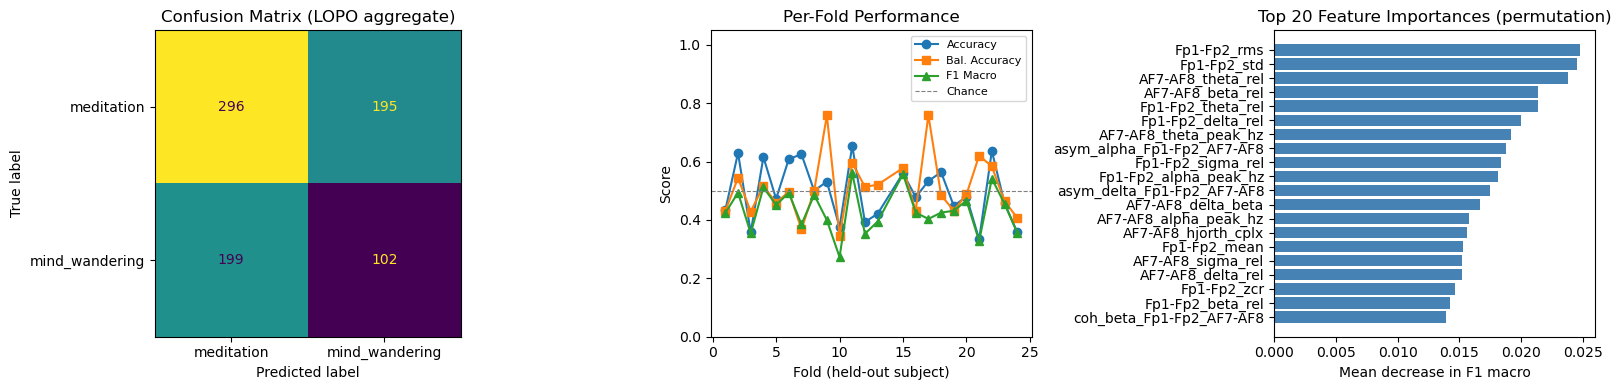

Saved lopo_results.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)
ConfusionMatrixDisplay(cm, display_labels=TARGET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (LOPO aggregate)")

# Per-fold metrics
axes[1].plot(folds_df["fold"], folds_df["accuracy"],     "o-", label="Accuracy")
axes[1].plot(folds_df["fold"], folds_df["balanced_acc"], "s-", label="Bal. Accuracy")
axes[1].plot(folds_df["fold"], folds_df["f1_macro"],     "^-", label="F1 Macro")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
axes[1].set_xlabel("Fold (held-out subject)")
axes[1].set_ylabel("Score")
axes[1].set_title("Per-Fold Performance")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.05)

# Feature importance via permutation (model-agnostic, works for SVC)
print("Computing permutation importance (may take ~1 min)...")
final_model = make_pipeline()
final_model.fit(X_sess, y)
perm = permutation_importance(
    final_model, X_sess, y,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1_macro",
)
importances = perm.importances_mean
top_n  = 20
top_idx = np.argsort(importances)[::-1][:top_n]
axes[2].barh([feat_names[i] for i in top_idx[::-1]],
             importances[top_idx[::-1]], color="steelblue")
axes[2].set_title(f"Top {top_n} Feature Importances (permutation)")
axes[2].set_xlabel("Mean decrease in F1 macro")

plt.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ARTIFACTS_DIR / "lopo_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved lopo_results.png")

## Threshold Tuning

SVC with `probability=True` outputs calibrated probabilities. The default threshold of 0.5 often underpredicts the minority class. Sweeping the threshold using the LOPO-collected probabilities finds the value that maximises F1 macro without re-training.

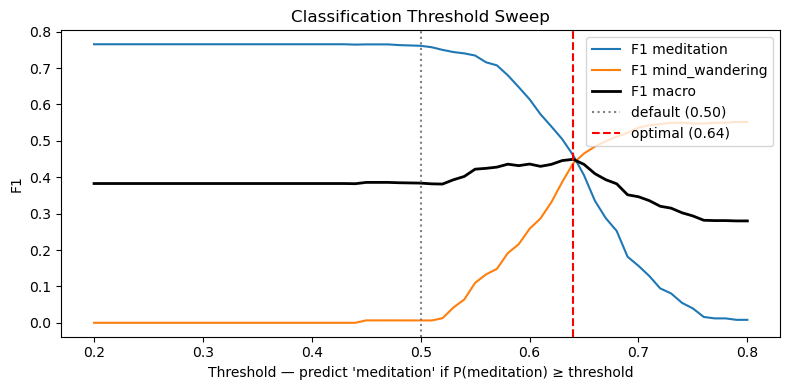

Default  threshold (0.50) → F1 macro: 0.384
Optimal  threshold (0.64) → F1 macro: 0.449  (+0.065)

--- Report at default threshold (0.50) ---
                precision    recall  f1-score   support

    meditation       0.60      0.60      0.60       491
mind_wandering       0.34      0.34      0.34       301

      accuracy                           0.50       792
     macro avg       0.47      0.47      0.47       792
  weighted avg       0.50      0.50      0.50       792

--- Report at optimal threshold (0.64) ---
                precision    recall  f1-score   support

    meditation       0.59      0.38      0.46       491
mind_wandering       0.36      0.56      0.44       301

      accuracy                           0.45       792
     macro avg       0.47      0.47      0.45       792
  weighted avg       0.50      0.45      0.45       792



In [12]:
# Sweep classification threshold using LOPO-collected probabilities.
# Default threshold (0.5) may underpredict meditation — tuning balances per-class F1.
thresholds = np.linspace(0.2, 0.8, 61)
f1_med, f1_mw, f1_mac = [], [], []
y_proba_arr = np.array(y_proba)

for t in thresholds:
    y_pred_t = np.where(y_proba_arr >= t, "meditation", "mind_wandering")
    f1_med.append(f1_score(y_true, y_pred_t, pos_label="meditation",     zero_division=0))
    f1_mw.append( f1_score(y_true, y_pred_t, pos_label="mind_wandering", zero_division=0))
    f1_mac.append(f1_score(y_true, y_pred_t, average="macro",            zero_division=0))

best_t   = thresholds[np.argmax(f1_mac)]
best_f1  = max(f1_mac)
default_f1 = f1_mac[np.argmin(np.abs(thresholds - 0.5))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_med, label="F1 meditation")
ax.plot(thresholds, f1_mw,  label="F1 mind_wandering")
ax.plot(thresholds, f1_mac, label="F1 macro", linewidth=2, color="black")
ax.axvline(0.5,    color="gray", linestyle=":",  label="default (0.50)")
ax.axvline(best_t, color="red",  linestyle="--", label=f"optimal ({best_t:.2f})")
ax.set_xlabel("Threshold — predict 'meditation' if P(meditation) ≥ threshold")
ax.set_ylabel("F1")
ax.set_title("Classification Threshold Sweep")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "threshold_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default  threshold (0.50) → F1 macro: {default_f1:.3f}")
print(f"Optimal  threshold ({best_t:.2f}) → F1 macro: {best_f1:.3f}  (+{best_f1 - default_f1:.3f})")

# Classification report at optimal threshold
y_pred_tuned = np.where(y_proba_arr >= best_t, "meditation", "mind_wandering")
print(f"\n--- Report at default threshold (0.50) ---")
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))
print(f"--- Report at optimal threshold ({best_t:.2f}) ---")
print(classification_report(y_true, y_pred_tuned, target_names=TARGET_LABELS, zero_division=0))

## Real-Time Benchmark

Measure feature extraction and SVM inference time on this machine, then estimate latency on the nRF54L15 (Cortex-M33 @ 128 MHz) using known CMSIS-DSP cycle counts for `arm_rfft_fast_f32`.

In [ ]:
# Benchmark feature extraction to show real-time viability on nRF54L15 (Cortex-M33)
n_ch       = len(channel_names)
n_pairs    = n_ch * (n_ch - 1) // 2
sample_seg = np.random.randn(n_ch, int(fs * WINDOW_SEC)).astype(np.float32)

N = 200
t0 = time.perf_counter()
for _ in range(N):
    extract_features(sample_seg, fs)
pc_ms = (time.perf_counter() - t0) / N * 1000

# Time SVM inference separately
N_inf = 500
sample_feat = extract_features(sample_seg, fs).reshape(1, -1)
t0 = time.perf_counter()
for _ in range(N_inf):
    final_model.predict_proba(sample_feat)
infer_ms = (time.perf_counter() - t0) / N_inf * 1000

# nRF54L15 Cortex-M33 @ 128 MHz estimate with CMSIS-DSP
# arm_rfft_fast_f32(256) ≈ 1000 cycles ≈ 8 µs at 128 MHz
# Welch on WINDOW_SEC: ceil(2*WINDOW_SEC) segments per channel
n_segments   = math.ceil(2 * WINDOW_SEC)
fft_us       = n_segments * n_ch * 8    # per-channel Welch FFTs
scalar_us    = 200                       # band sums, Hjorth, ratios, ZCR, log-asymmetry, SEF95 (2 ch)
pe_us        = n_ch * 150               # permutation entropy O(n) per channel
svm_us       = 800                       # O(n_support × n_features)
m33_total_ms = (fft_us + scalar_us + pe_us + svm_us) / 1000

budget_ms = WINDOW_SEC * 1000
headroom  = budget_ms - m33_total_ms

print(f"Channels: {n_ch}  |  pairs: {n_pairs}  |  features: {len(feat_names)}")
print(f"Feature extraction  PC (Python):        {pc_ms:.1f} ms")
print(f"SVM inference       PC (Python):        {infer_ms:.2f} ms")
print()
print(f"M33 estimate (CMSIS-DSP arm_rfft_fast_f32):")
print(f"  FFT  ({n_segments} segs × {n_ch} ch × 8 µs):        {fft_us} µs")
print(f"  Scalar ops (bands, Hjorth, SEF95):      {scalar_us} µs")
print(f"  Permutation entropy ({n_ch} ch):          {pe_us} µs")
print(f"  SVM inference:                          {svm_us} µs")
print(f"  Total:                                  {m33_total_ms:.1f} ms")
print()
print(f"Window budget:  {budget_ms:.0f} ms")
print(f"Headroom:       {headroom:.0f} ms  ({headroom/budget_ms*100:.0f}% of budget remaining)")
print(f"Real-time viable: {'YES' if headroom > 0 else 'NO'}")

## Firmware-Viable Feature Set

Drop the 3 coherence features (`coh_theta`, `coh_alpha`, `coh_beta`): they require cross-spectrum computation (`arm_cmplx_mult_cmplx_f32` + magnitude-squared per bin), which is non-trivial firmware code. Lateralization is already captured by the log-asymmetry features (`asym_*`), which are just `log(P_Fp2) − log(P_Fp1)` computed from band powers already in hand.

All remaining 61 features use only `arm_rfft_fast_f32` + scalar arithmetic (`CONFIG_CMSIS_DSP=y`).

In [14]:
# Coherence requires cross-spectrum computation (arm_cmplx_mult_cmplx_f32 + magnitude-squared
# per bin) for every pair — significant firmware complexity vs. log-asymmetry which is just
# log(P_j) - log(P_i) from band powers already in hand. Drop all coh_* features.
FW_EXCLUDE    = {n for n in feat_names if n.startswith("coh_")}
fw_feat_names = [n for n in feat_names if n not in FW_EXCLUDE]
fw_mask       = np.array([n not in FW_EXCLUDE for n in feat_names])
X_fw          = X_sess[:, fw_mask]

n_pairs = len(channel_names) * (len(channel_names) - 1) // 2
print(f"Full model:     {len(feat_names)} features  ({n_pairs} pairs × 3 coh + rest)")
print(f"Firmware model: {len(fw_feat_names)} features  (dropped {len(FW_EXCLUDE)} coherence features)")
print()

print("Running LOPO for firmware feature set...")
fw_fold_results, fw_y_true, fw_y_pred, _ = run_lopo(X_fw, y, groups)
fw_df = pd.DataFrame(fw_fold_results)

print()
print(f"{'Metric':<20} {'Full model':>12} {'Firmware':>10} {'Delta':>8}")
print("-" * 52)
for col, label in [("accuracy", "Accuracy"), ("balanced_acc", "Balanced Acc"), ("f1_macro", "F1 Macro")]:
    full_val = folds_df[col].mean()
    fw_val   = fw_df[col].mean()
    print(f"{label:<20} {full_val:>12.3f} {fw_val:>10.3f} {fw_val - full_val:>+8.3f}")

Full model:     78 features  (1 pairs × 3 coh + rest)
Firmware model: 75 features  (dropped 3 coherence features)

Running LOPO for firmware feature set...
  Fold  1 | held-out: sub-001 | acc=0.453 | bal_acc=0.446 | F1=0.440 | rec_med=0.47 | rec_mw=0.42 | best=10/{'meditation': 1, 'mind_wandering': 3}
  Fold  2 | held-out: sub-002 | acc=0.648 | bal_acc=0.494 | F1=0.475 | rec_med=0.70 | rec_mw=0.29 | best=10/{'meditation': 1, 'mind_wandering': 2}
  Fold  3 | held-out: sub-003 | acc=0.464 | bal_acc=0.595 | F1=0.464 | rec_med=0.33 | rec_mw=0.86 | best=10/{'meditation': 1, 'mind_wandering': 2}
  Fold  4 | held-out: sub-004 | acc=0.615 | bal_acc=0.517 | F1=0.511 | rec_med=0.70 | rec_mw=0.33 | best=10/{'meditation': 1, 'mind_wandering': 3}
  Fold  5 | held-out: sub-005 | acc=0.417 | bal_acc=0.417 | F1=0.405 | rec_med=0.42 | rec_mw=0.42 | best=10/balanced
  Fold  6 | held-out: sub-006 | acc=0.652 | bal_acc=0.597 | F1=0.571 | rec_med=0.69 | rec_mw=0.50 | best=10/{'meditation': 1, 'mind_wanderi

In [15]:
# Train final firmware model on reduced feature set and export
fw_final = make_pipeline()
fw_final.fit(X_fw, y)
n_fw_features = len(fw_feat_names)

fw_onnx = convert_sklearn(
    fw_final,
    initial_types=[("input", FloatTensorType([None, n_fw_features]))],
)
fw_onnx_path = ARTIFACTS_DIR / "meditation_model_fw.onnx"
fw_onnx_path.write_bytes(fw_onnx.SerializeToString())

fw_schema = {
    "input_name":    "input",
    "dtype":         "float32",
    "window_sec":    WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "n_features":    n_fw_features,
    "feature_names": fw_feat_names,
    "excluded_vs_full": sorted(FW_EXCLUDE),
    "classification_threshold": float(best_t),
    "zephyr_note": (
        "All features computable with CONFIG_CMSIS_DSP=y. "
        "Use arm_rfft_fast_f32(256) for Welch PSD segments, then scalar band summation. "
        "Coherence dropped — lateralization captured by log-asymmetry features instead."
    ),
    "outputs": TARGET_LABELS,
}
fw_schema_path = ARTIFACTS_DIR / "feature_schema_fw.json"
fw_schema_path.write_text(json.dumps(fw_schema, indent=2), encoding="utf-8")
print(f"Firmware ONNX saved:   {fw_onnx_path}")
print(f"Firmware schema saved: {fw_schema_path}")

Firmware ONNX saved:   artifacts\meditation_model_fw.onnx
Firmware schema saved: artifacts\feature_schema_fw.json


## Export — ONNX Model & Feature Schema

In [16]:
# ONNX export
onnx_model = convert_sklearn(
    final_model,
    initial_types=[("input", FloatTensorType([None, n_features]))],
)
onnx_path = ARTIFACTS_DIR / "meditation_model_snoozy.onnx"
onnx_path.write_bytes(onnx_model.SerializeToString())
print(f"ONNX model saved: {onnx_path}")

# Joblib export (for quick Python inference during development)
joblib_path = ARTIFACTS_DIR / "meditation_model_snoozy.joblib"
joblib.dump(final_model, joblib_path)
print(f"Joblib model saved: {joblib_path}")

# Feature schema for the Snoozy firmware / app
schema = {
    "input_name": "input",
    "dtype": "float32",
    "window_sec": WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "hardware_referencing": (
        "Two bipolar EEG derivations: (Fp1−Fp2)−Fpz and (AF7−AF8)−Fpz. "
        "ADS1299-4 Ch1: A(Fp1) − B(Fp2), Ch2: A(AF7) − B(AF8), BIAS/REF: Fpz. "
        "Subtract the Fpz sample from each bipolar output before feature extraction."
    ),
    "n_features": n_features,
    "feature_names": feat_names,
    "bands_hz": {k: list(v) for k, v in BANDS.items()},
    "sub_bands_hz": {k: list(v) for k, v in SUB_BANDS.items()},
    "bandpass_hz": [LOWCUT, HIGHCUT],
    "classification_threshold": float(best_t),
    "outputs": TARGET_LABELS,
    "lopo_cv": {
        "mean_accuracy":     float(folds_df["accuracy"].mean()),
        "std_accuracy":      float(folds_df["accuracy"].std()),
        "mean_balanced_acc": float(folds_df["balanced_acc"].mean()),
        "mean_f1_macro":     float(folds_df["f1_macro"].mean()),
        "mean_recall_mw":    float(folds_df["recall_mw"].mean()),
        "n_subjects":        int(len(folds_df)),
    },
    "notes": (
        "Binary meditation vs. mind_wandering classifier for Snoozy (nRF54L15 + ADS1299-4). "
        "Input to ONNX is the engineered feature vector, not raw EEG. "
        f"Features extracted from {len(channel_names)}-channel {WINDOW_SEC:.0f}s EEG window. "
        "Trained on OpenNeuro ds001787 with LOPO CV. "
        "Use classification_threshold instead of 0.5 — tuned to maximise F1 macro."
    ),
}

schema_path = ARTIFACTS_DIR / "feature_schema_snoozy.json"
schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8")
print(f"Feature schema saved: {schema_path}")

ONNX model saved: artifacts\meditation_model_snoozy.onnx
Joblib model saved: artifacts\meditation_model_snoozy.joblib
Feature schema saved: artifacts\feature_schema_snoozy.json


## Sanity Check — ONNX Inference

In [17]:
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path))
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Use session-normalized features — the model was trained on X_sess
sample = X_sess[:1].astype(np.float32)
sklearn_pred = final_model.predict(sample)[0]
onnx_pred    = sess.run([output_name], {input_name: sample})[0][0]

print(f"sklearn prediction : {sklearn_pred}")
print(f"ONNX   prediction  : {onnx_pred}")
assert sklearn_pred == onnx_pred, "Prediction mismatch between sklearn and ONNX!"
print("ONNX sanity check passed.")
print(f"\nONNX input shape expected: [batch, {n_features}]")
print(f"Note: features must be session-z-scored before inference (subtract session mean, divide by session std)")

sklearn prediction : mind_wandering
ONNX   prediction  : mind_wandering
ONNX sanity check passed.

ONNX input shape expected: [batch, 78]
Note: features must be session-z-scored before inference (subtract session mean, divide by session std)
